In [1]:
%load_ext autoreload
%autoreload 2

In [27]:
import h5py

import tensorflow as tf
tf.config.experimental.set_memory_growth(tf.config.list_physical_devices(device_type="GPU")[0], True)

import numpy as np
import healpy as hp
import matplotlib.pyplot as plt

from tqdm import tqdm
from icecream import ic

from msfm.grid_pipeline import GridPipeline
from msfm.fiducial_pipeline import FiducialPipeline
from msfm.utils import logger, input_output, files, scales, power_spectra, parameters

from deep_lss.nets.custom_layers import MeanBinningLayer
from deep_lss.models.grid_model import GridLossModel
from deep_lss.utils import optimization
from deep_lss.nets.gaussian_mixture import GaussianMixtureModel
from deep_lss.nets.mlp import MultiLayerPerceptron

from msi.utils import preprocessing, dataset

In [3]:
conf = files.load_config("/global/homes/a/athomsen/multiprobe-simulation-forward-model/configs/v9/linear_bias.yaml")

base_dir = "/pscratch/sd/a/athomsen/v11desy3/v9/linear_bias"
out_dir = "/pscratch/sd/a/athomsen/run_files/v9"

with_lensing = True
with_clustering = False
params = ["Om", "s8", "w0", "Aia", "n_Aia"]
# params = ["Om", "s8"]

In [4]:
batch_size = 2**12
# batch_size = 2**8
shuffle_buffer = 4*batch_size

l_mins = 8 * [30]
def angle_to_ell(angles):
    return list(scales.angle_to_ell(np.array(angles), arcmin=True))
l_maxs = angle_to_ell([22.1, 15.1, 11.2, 9.4] + [65.1, 44.5, 34.1, 28.5])
n_bins = 33

apply_log = True
standardize = True
pca_components = None

cl_dset_train, cl_dset_test, out_dict = dataset.get_binned_power_spectra_dset(
    base_dir, 
    # configuration
    conf=conf, 
    params=params,
    # selection
    with_lensing=with_lensing,
    with_clustering=with_clustering,
    # dset
    batch_size=batch_size,
    shuffle_buffer=shuffle_buffer,
    # power spectra
    l_mins=l_mins,
    l_maxs=l_maxs,
    n_bins=n_bins,
    # additional preprocessing
    apply_log=apply_log,
    standardize=standardize,
    pca_components=pca_components,

)

24-08-22 02:12:02 preprocessin INF   Applying scale cuts to the raw Cls 
24-08-22 02:12:02 preprocessin INF   l_mins = [30, 30, 30, 30, 30, 30, 30, 30] 
24-08-22 02:12:02 preprocessin INF   l_maxs = [488.6877828054298, 715.2317880794702, 964.2857142857142, 1148.936170212766, 165.89861751152074, 242.69662921348313, 316.7155425219941, 378.94736842105266] 
24-08-22 02:12:05 input_output INF   Array shapes: 
24-08-22 02:12:05 input_output INF   fiducial/i_example = (40000,) 
24-08-22 02:12:05 input_output INF   fiducial/i_noise   = (40000,) 
24-08-22 02:12:05 input_output INF   fiducial/cls/binned = (40000, 32, 36) 
24-08-22 02:12:05 input_output INF   fiducial/cls/bin_edges = (33, 36) 
24-08-22 02:12:05 input_output INF   grid/cosmo         = (2500, 240, 12) 
24-08-22 02:12:05 input_output INF   grid/i_example     = (2500, 240) 
24-08-22 02:12:05 input_output INF   grid/i_noise       = (2500, 240) 
24-08-22 02:12:05 input_output INF   grid/i_sobol       = (2500, 240) 
24-08-22 02:12:06 in

In [5]:
class MLP(tf.keras.Model):
    def __init__(self, output_size, num_hidden_units, num_layers, dropout_rate=0.0, normalization="layer", activation="relu"):
        super(MLP, self).__init__()
        if normalization == "layer":
            self.norm_layer = tf.keras.layers.LayerNormalization()
        elif normalization == "batch":
            self.norm_layer = tf.keras.layers.BatchNormalization()
        else:
            raise ValueError
            
        self.hidden_layers = []
        for _ in range(num_layers):
            self.hidden_layers.append(tf.keras.layers.Dense(num_hidden_units, activation=activation))
            if dropout_rate > 0:
                self.hidden_layers.append(tf.keras.layers.Dropout(dropout_rate))
        self.output_layer = tf.keras.layers.Dense(output_size)

    def call(self, inputs):
        x = self.norm_layer(inputs)
        for layer in self.hidden_layers:
            x = layer(x)
        return self.output_layer(x)

# Jensen-Shannon-Divergence (JSD)

In [22]:
def mutual_info_loss(T, x, theta, m=16, training=True):
    # eq. (4) or Appendix B.1 in https://arxiv.org/pdf/2010.10079
    n = tf.shape(x)[0]

    # sp(-T(θi, S(xi)))
    term_1 = tf.reduce_mean(tf.math.softplus(-T([x, theta], training=training)))

    term_2 = 0
    for _ in range(m):
        permuted_indices = tf.random.shuffle(tf.range(n))
        permuted_theta = tf.gather(theta, permuted_indices)
        
        # sp(T(θji, S(xi))) for each pair (θji, S(xi))
        term_2 += tf.reduce_mean(tf.math.softplus(T([x, permuted_theta], training=training)))
    
    term_2 /= m
        
    return term_1 + term_2

In [23]:
n_cls = out_dict["grid/cls/train"].shape[-1]
n_params = len(params)
n_summary = 2 * n_params
dropout_rate = 0.1

S = MLP(output_size=n_summary, num_hidden_units=256, num_layers=4, dropout_rate=dropout_rate)
H = MLP(output_size=n_params, num_hidden_units=128, num_layers=2, dropout_rate=dropout_rate)
t = MLP(output_size=1, num_hidden_units=128, num_layers=2, dropout_rate=dropout_rate)

input_S = tf.keras.Input(shape=(n_cls,))
input_H = tf.keras.Input(shape=(n_params,))

output_S = S(input_S)
output_H = H(input_H)
output_t = t(tf.concat([output_S, output_H], axis=-1))

T = tf.keras.Model(inputs=[input_S, input_H], outputs=output_t)

In [24]:
@tf.function()
def train_step(T, x_batch, theta_batch, optimizer):
    with tf.GradientTape() as tape:
        loss = mutual_info_loss(T, x_batch, theta_batch)
    
    # Compute gradients and apply them
    gradients = tape.gradient(loss, T.trainable_variables)
    optimizer.apply_gradients(zip(gradients, T.trainable_variables))

    return loss

10001it [06:24, 26.04it/s]                          


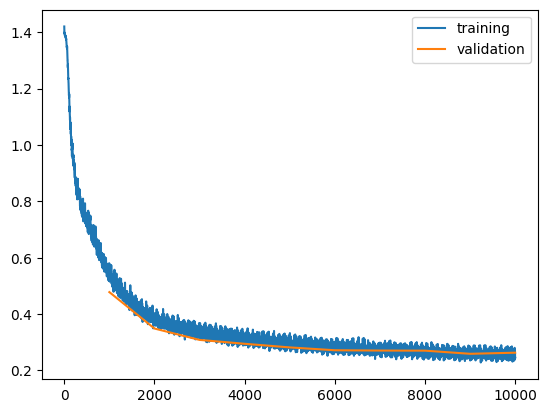

In [25]:
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4)

@tf.function
def vali_loss_fn(x_batch, theta_batch):
    return mutual_info_loss(T, x_batch, theta_batch, m=16, training=False)

n_steps = 10_000
train_losses = []
vali_steps = []
vali_losses = []
for i, (cl_batch, cosmo_batch) in tqdm(enumerate(cl_dset_train.take(n_steps+1)), total=n_steps):
    train_losses.append(train_step(T, cl_batch, cosmo_batch, optimizer))
    
    if i % 1_000 == 0 and i !=0:
        vali_loss = []
        for cl_batch, cosmo_batch in cl_dset_test:
            vali_loss.append(vali_loss_fn(cl_batch, cosmo_batch))
        vali_losses.append(np.mean(vali_loss))
        vali_steps.append(i)
    
fig, ax = plt.subplots()
ax.plot(train_losses, label="training")
ax.plot(vali_steps, vali_losses, label="validation")
ax.legend()

In [26]:
# optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4)

# n_steps = 10_000
# losses = []
# for cl_batch, cosmo_batch in tqdm(cl_dset_train.take(n_steps), total=n_steps):
#     loss = train_step(T, cl_batch, cosmo_batch, optimizer)
#     losses.append(loss)
    
# plt.plot(losses)

In [27]:
np.save("./predictions/mutual(jsd)_grid_preds.npy", S(out_dict["grid/cls/test"]))
np.save("./predictions/mutual(jsd)_grid_cosmos.npy", out_dict["grid/cosmos/test"])
np.save("./predictions/mutual(jsd)_fidu_preds.npy", S(out_dict["fidu/cls"]))

# Distance Correlation (DC)

In [28]:
# def safe_norm(x, epsilon=1e-12, axis=None):
#     return tf.sqrt(tf.reduce_sum(tf.square(x), axis=axis) + epsilon)

# def h_tilde(a, b, eps=1e-8):
#     n = tf.shape(a)[0]
    
#     # pairwise differences
#     # diff_ij = tf.norm(a[:, tf.newaxis] - b[tf.newaxis, :], axis=-1, ord="euclidean") + eps
#     diff_ij = safe_norm(a[:, tf.newaxis] - b[tf.newaxis, :], axis=-1)
    
#     term1 = diff_ij
#     term2 = tf.reduce_mean(diff_ij, axis=1, keepdims=True)  
#     term3 = tf.reduce_mean(diff_ij, axis=0, keepdims=True)
#     term4 = tf.reduce_mean(diff_ij)  
    
#     result = term1 - term2 - term3 + term4
        
#     return result

In [29]:
# def mutual_info_loss_dc(S, x, theta, eps=1e-8, training=True):
#     n = tf.shape(theta)[0]

#     S_x = S(x, training=training)
    
#     # Compute h_tilde for (theta_i, theta_j) and (S(x_i), S(x_j))
#     h_theta = h_tilde(theta, theta)
#     h_Sx = h_tilde(S_x, S_x)
    
#     # numerator: sum over i,j h_tilde(theta_i, theta_j) * h_tilde(S(x_i), S(x_j))
#     numerator = tf.reduce_mean(h_theta * h_Sx)
    
#     # denominator: product of sqrt sums
#     sum_h_theta_squared = tf.reduce_mean(tf.square(h_theta))
#     sum_h_Sx_squared = tf.reduce_mean(tf.square(h_Sx))
#     denominator = tf.sqrt(sum_h_theta_squared + eps) * tf.sqrt(sum_h_Sx_squared + eps)
        
#     loss = - tf.math.divide_no_nan(numerator, denominator + eps)
        
#     return loss

In [25]:
# n_cls = out_dict["grid/cls/train"].shape[-1]
# n_params = len(params)
# n_summary = 2 * n_params
# dropout_rate = 0.1

# S = MLP(output_size=n_summary, num_hidden_units=256, num_layers=4, dropout_rate=dropout_rate, activation="relu")

In [31]:
from deep_lss.utils.mutual_info_loss import distance_correlation
mutual_info_loss = distance_correlation

In [32]:
n_cls = out_dict["grid/cls/train"].shape[-1]
n_params = len(params)
n_summary = 2 * n_params
dropout_rate = 0.1

S = MultiLayerPerceptron(
    output_size=n_summary, 
    num_hidden_units=256, 
    num_layers=4, 
    dropout_rate=dropout_rate, 
    activation="relu"
)


In [33]:
@tf.function()
def train_step(S, x_batch, theta_batch, optimizer):
    with tf.GradientTape() as tape:
        loss = mutual_info_loss_dc(S, x_batch, theta_batch)
    
    # Compute gradients and apply them
    gradients = tape.gradient(loss, S.trainable_variables)
    # gradients, _ = tf.clip_by_global_norm(gradients, 1.0)
        
    optimizer.apply_gradients(zip(gradients, S.trainable_variables))

    return loss

1001it [00:20, 50.04it/s]                         


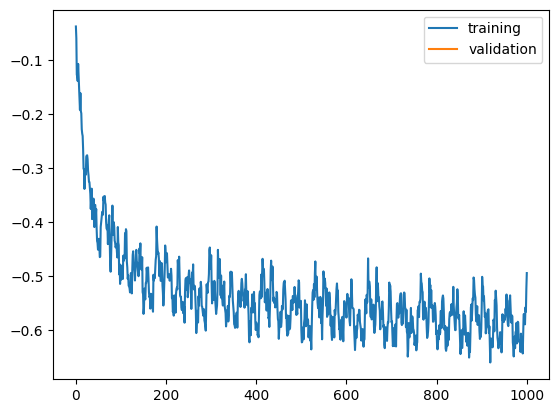

In [34]:
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4)

@tf.function
def vali_loss_fn(x_batch, theta_batch):
    return mutual_info_loss_dc(S, x_batch, theta_batch, training=False)

n_steps = 1_000
train_losses = []
vali_steps = []
vali_losses = []
for i, (cl_batch, cosmo_batch) in tqdm(enumerate(cl_dset_train.take(n_steps+1)), total=n_steps):
    train_losses.append(train_step(S, cl_batch, cosmo_batch, optimizer))
    
    if i % 1_000 == 0 and i !=0:
        vali_loss = []
        for cl_batch, cosmo_batch in cl_dset_test:
            vali_loss.append(vali_loss_fn(cl_batch, cosmo_batch))
        vali_losses.append(np.mean(vali_loss))
        vali_steps.append(i)
    
fig, ax = plt.subplots()
ax.plot(train_losses, label="training")
ax.plot(vali_steps, vali_losses, label="validation")
ax.legend()

In [20]:
# optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4)

# n_steps = 10_000
# losses = []
# for cl_batch, cosmo_batch in tqdm(cl_dset_train.take(n_steps), total=n_steps):
#     assert not tf.reduce_any(tf.math.is_nan(cl_batch)), "x_batch contains NaNs"
#     assert not tf.reduce_any(tf.math.is_nan(cosmo_batch)), "theta_batch contains NaNs"
    
#     loss = train_step(S, cl_batch, cosmo_batch, optimizer)
#     losses.append(loss)
    
# plt.plot(losses)

In [35]:
np.save("./predictions/mutual(dc)_grid_preds.npy", S(out_dict["grid/cls/test"]))
np.save("./predictions/mutual(dc)_grid_cosmos.npy", out_dict["grid/cosmos/test"])
np.save("./predictions/mutual(dc)_fidu_preds.npy", S(out_dict["fidu/cls"]))

# variational lower bound

In [15]:
# n_cls = out_dict["grid/cls/train"].shape[-1]
# n_params = len(params)
# n_summary = 2 * n_params
# dropout_rate = 0.1

# S = MultiLayerPerceptron(
#     output_size=n_summary, 
#     num_hidden_units=256, 
#     num_layers=4, 
#     dropout_rate=dropout_rate, 
#     activation="relu"
# )

# GMM = GaussianMixtureModel(
#     dim_theta=n_params, 
#     dim_summary=n_summary, 
#     num_components=4,
#     num_hidden_layers=2,
#     num_hidden_units=128,
#     activation="relu", 
# )

# input_cls = tf.keras.Input(shape=(n_cls,))
# input_theta = tf.keras.Input(shape=(n_params,))
# output = GMM.log_prob(input_theta, S(input_cls))
# T = tf.keras.Model(inputs=[input_cls, input_theta], outputs=output)

In [16]:
# @tf.function()
# def train_step(T, x_batch, theta_batch, optimizer):
#     with tf.GradientTape() as tape:
#         loss = - tf.reduce_mean(T([x_batch, theta_batch]))
    
#     # Compute gradients and apply them
#     gradients = tape.gradient(loss, T.trainable_variables)

#     gradients, _ = tf.clip_by_global_norm(gradients, 1.0)
        
#     optimizer.apply_gradients(zip(gradients, T.trainable_variables))

#     return loss

In [46]:
n_cls = out_dict["grid/cls/train"].shape[-1]
n_params = len(params)
n_summary = 2 * n_params
dropout_rate = 0.1

S = MultiLayerPerceptron(
    output_size=n_summary, 
    num_hidden_units=256, 
    num_layers=4, 
    dropout_rate=dropout_rate, 
    activation="relu"
)

GMM = GaussianMixtureModel(
    dim_theta=n_params, 
    dim_summary=n_summary, 
    num_components=4,
    num_hidden_layers=2,
    num_hidden_units=128,
    activation="relu", 
)

input_summary = tf.keras.Input(shape=(n_summary,))
input_theta = tf.keras.Input(shape=(n_params,))
output = - GMM.log_prob(input_theta, input_summary)
T = tf.keras.Model(inputs=[input_summary, input_theta], outputs=output)

In [47]:
@tf.function()
def train_step(S, T, x_batch, theta_batch, optimizer):
    with tf.GradientTape() as tape:
        s_batch = S(x_batch)
        loss = tf.reduce_mean(T([s_batch, theta_batch]))
    
    # Compute gradients and apply them
    gradients = tape.gradient(loss, T.trainable_variables)

    gradients, _ = tf.clip_by_global_norm(gradients, 1.0)
        
    optimizer.apply_gradients(zip(gradients, T.trainable_variables))

    return loss

In [48]:
# optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4)

# @tf.function
# def vali_loss_fn(x_batch, theta_batch):
#     return - tf.reduce_mean(T([x_batch, theta_batch], training=False))

# n_steps = 10_000
# train_losses = []
# vali_steps = []
# vali_losses = []
# for i, (cl_batch, cosmo_batch) in tqdm(enumerate(cl_dset_train.take(n_steps+1)), total=n_steps):
#     train_losses.append(train_step(S, T, cl_batch, cosmo_batch, optimizer))
    
#     if i % 1_000 == 0 and i !=0:
#         vali_loss = []
#         for cl_batch, cosmo_batch in cl_dset_test:
#             vali_loss.append(vali_loss_fn(cl_batch, cosmo_batch))
#         vali_losses.append(np.mean(vali_loss))
#         vali_steps.append(i)
    
# fig, ax = plt.subplots()
# ax.plot(train_losses, label="training")
# ax.plot(vali_steps, vali_losses, label="validation")
# ax.legend()

In [49]:
# np.save("./predictions/mutual(var)_grid_preds.npy", S(out_dict["grid/cls/test"]))
# np.save("./predictions/mutual(var)_grid_cosmos.npy", out_dict["grid/cosmos/test"])
# np.save("./predictions/mutual(var)_fidu_preds.npy", S(out_dict["fidu/cls"]))

100%|██████████| 1000/1000 [00:06<00:00, 145.70it/s]


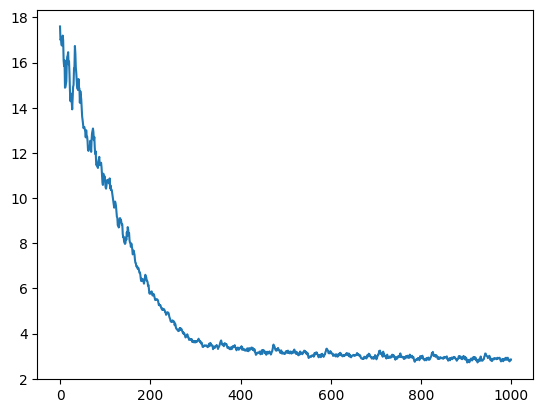

In [50]:
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4)

n_steps = 1_000
losses = []
for cl_batch, cosmo_batch in tqdm(cl_dset_train.take(n_steps), total=n_steps):    
    loss = train_step(S, T, cl_batch, cosmo_batch, optimizer)
    losses.append(loss)
    
plt.plot(losses)